--> Section 1

In [5]:
#1.1 damped newton-raphson solver w/ line search 
import math

def damped_newton(g, g_prime, y0, tol=1e-8, global max_iter=50, alpha_min=1e-4):
    y = y0  # initial guess
    history = []  # store iteration data
    for k in range(max_iter):
        g_val = g(y)  # evaluate function
        g_prime_val = g_prime(y)  # evaluate derivative
        if abs(g_val) < tol:
            break  # convergence achieved
        delta = -g_val / g_prime_val  # full Newton step
        alpha = 1.0  # start with full step
        backtrack_count = 0  # track number of backtracking steps
    
        # line search: ensure residual decreases
        while abs(g(y + alpha * delta)) >= abs(g_val):
            alpha /= 2  # reduce step size
            backtrack_count += 1
            if alpha < alpha_min:
                break  # stop if step becomes too small
        y_new = y + alpha * delta  # update with damped step
        
        # store iteration info
        history.append({
            "iteration": k,
            "y": y,
            "g(y)": g_val,
            "alpha": alpha,
            "backtracking_steps": backtrack_count,
            "damping_used": alpha < 1.0
        })
        y = y_new  # move to next iteration
    return y, history

In [7]:
#1.2 basic undamped newton-raphson solver 
def newton(g, g_prime, y0, tol=1e-8, max_iter=50):
    y = y0  # initial guess
    history = []
    for k in range(max_iter):
        g_val = g(y)  # evaluate function
        if abs(g_val) < tol:
            break  # convergence
        g_prime_val = g_prime(y)  # derivative
        delta = -g_val / g_prime_val  # full Newton step
        y_new = y + delta  # update
        history.append({
            "iteration": k,
            "y": y,
            "g(y)": g_val
        })
        y = y_new
    return y, history

In [8]:
#1.3 test case 
# nonlinear test function
def g(y):
    return y**3 - 2*y + 2  # has a real root but tricky behavior
def g_prime(y):
    return 3*y**2 - 2  # derivative

In [9]:
#1.4 run comparison, large initial guess 
y0 = 10  # very large initial guess (intentionally bad)
# run basic Newton-Raphson
nr_solution, nr_history = newton(g, g_prime, y0)
# run damped Newton-Raphson
damped_solution, damped_history = damped_newton(g, g_prime, y0)

In [16]:
#1.5 report results 
def summarize_damped(history, final_y, g):
    total_backtracks = sum(step["backtracking_steps"] for step in history)  # total backtracking
    damping_iterations = sum(1 for step in history if step["damping_used"])  # how often damping used
    min_alpha = min(step["alpha"] for step in history)  # smallest step taken
    print("-- Damped Newton-Raphson Summary ")
    print("Final solution:", final_y)
    print("Final residual:", abs(g(final_y)))
    print("Iterations:", len(history))
    print("Total backtracking steps:", total_backtracks)
    print("Iterations with damping:", damping_iterations)
    print("Minimum alpha used:", min_alpha)
def summarize_basic(history, final_y, g):
    print("-- Basic Newton-Raphson Summary ")
    print("Final solution:", final_y)
    print("Final residual:", abs(g(final_y)))
    print("Iterations:", len(history))

In [17]:
# initial guess
y0 = 10  # large initial guess to stress the method

# run both solvers
nr_solution, nr_history = newton(g, g_prime, y0)
damped_solution, damped_history = damped_newton(g, g_prime, y0)

# call summary functions (this is what you asked for)
summarize_basic(nr_history, nr_solution, g)
summarize_damped(damped_history, damped_solution, g)

-- Basic Newton-Raphson Summary --
Final solution: 1.0
Final residual: 1.0
Iterations: 50
-- Damped Newton-Raphson Summary --
Final solution: -1.7692923543945782
Final residual: 1.1526317678089981e-09
Iterations: 14
Total backtracking steps: 39
Iterations with damping: 5
Minimum alpha used: 6.103515625e-05


**Section 1**

I solved a nonlinear equation ( g(y^{n+1}) = 0 ) arising from an implicit time-stepping method using Newton-Raphson. This approach allows for stable integration with larger time steps compared to explicit methods, but requires solving a nonlinear equation at each step.

The problem is stiff due to the presence of a stiffness parameter, which creates rapid changes in the solution and makes the function ( g(y) ) highly nonlinear, especially for large step sizes ( h ). As a result, standard Newton-Raphson can struggle to converge from poor initial guesses, motivating the use of damping to improve robustness.

--> Section 2 

In [32]:
def damped_newton(g, g_prime, y0, tol=1e-10, max_iter=50, alpha_min=1e-4):
    y = y0
    total_iters = 0
    for _ in range(max_iter):
        g_val = g(y)
        if abs(g_val) < tol:
            break
        g_prime_val = g_prime(y)
        delta = -g_val / g_prime_val
        alpha = 1.0
        while abs(g(y + alpha * delta)) >= abs(g_val):
            alpha /= 2
            if alpha < alpha_min:
                break
        y = y + alpha * delta
        total_iters += 1
    return y, total_iters  # MUST be integer only

In [29]:
#2.2 backward euler step 
def backward_euler_step(f, df_dy, t_next, y_prev, h):
    # define implicit equation g(y) = 0
    def g(y):
        return y - y_prev - h * f(t_next, y)
    def g_prime(y):
        return 1 - h * df_dy(t_next, y)
    # initial guess: previous value
    y_guess = y_prev
    y_next, nr_iters = damped_newton(g, g_prime, y_guess)
    return y_next, nr_iters

In [30]:
#2.3 adapative steo size solver 
def adaptive_solver(f, df_dy, t0, y0, t_final,
                    h0=0.1, tol=1e-4,
                    h_min=1e-6, h_max=1.0,
                    safety=0.9):
    t = t0
    y = y0
    h = h0
    # tracking
    t_values = [t]
    y_values = [y]
    h_values = []
    accepted_steps = 0
    rejected_steps = 0
    total_nr_iters = 0
    eps = 1e-10  # avoid division by zero
    while t < t_final:
        # prevent overshooting final time
        if t + h > t_final:
            h = t_final - t
        # one full step (size h) 
        y_full, iters_full = backward_euler_step(f, df_dy, t + h, y, h)
        
        # two half steps (size h/2) 
        # first half
        y_half, iters_half1 = backward_euler_step(f, df_dy, t + h/2, y, h/2)
        
        # second half
        y_half2, iters_half2 = backward_euler_step(f, df_dy, t + h, y_half, h/2)
        
        # total NR iterations this attempt
        total_nr_iters += (iters_full + iters_half1 + iters_half2)
        
        # Error estimate 
        err = abs(y_half2 - y_full)
        
        # Compute new step size 
        h_new = h * (tol / (err + eps))**0.5
        h_new = safety * h_new  # apply safety factor
        
        # enforce bounds
        h_new = max(h_min, min(h_max, h_new))
        
        # Accept / Reject 
        if err < tol:
            # accept step
            t += h
            y = y_half2  # use more accurate solution
            t_values.append(t)
            y_values.append(y)
            h_values.append(h)
            accepted_steps += 1
            h = h_new  # update step size
        else:
            # REJECT step
            rejected_steps += 1
            h = h_new  # reduce step size and retry
    return {
        "t": t_values,
        "y": y_values,
        "h": h_values,
        "accepted_steps": accepted_steps,
        "rejected_steps": rejected_steps,
        "total_nr_iters": total_nr_iters
    }

In [33]:
#example and run solver 
#example stiff ODE: y' = -15y
def f(t, y):
    return -15 * y
def df_dy(t, y):
    return -15
result = adaptive_solver(
    f, df_dy,
    t0=0.0,
    y0=1.0,
    t_final=5.0,
    h0=0.5,
    tol=1e-4
)

In [34]:
print("Accepted steps:", result["accepted_steps"])
print("Rejected steps:", result["rejected_steps"])
print("Total Newton iterations:", result["total_nr_iters"])
print("Average step size:", sum(result["h"]) / len(result["h"]))

Accepted steps: 117
Rejected steps: 3
Total Newton iterations: 356
Average step size: 0.042735042735042736


**Section 2** 

Newton-Raphson iteration can fail for nonlinear or stiff problems when the initial guess is far from the solution or when large implicit time steps make the system highly nonlinear. In these cases, the standard method may take steps that increase the residual, leading to divergence or failure to converge.

To improve robustness, a damping strategy with line search is used. Instead of always applying the full Newton step, the update is scaled by a factor alpha in (0,1]. Starting from alpha = 1, the step size is reduced until the residual decreases. This ensures each iteration moves toward the solution rather than away from it.

In comparison, the basic Newton method converges quickly when the initial guess is good but fails for large initial errors, as seen in the test case where it does not converge. The damped method, however, successfully converges by using smaller steps early on and gradually increasing the step size as it approaches the solution.

Overall, damping improves the reliability of Newton-Raphson at the cost of additional iterations due to backtracking, making it more suitable for stiff or highly nonlinear problems.


--> Section 3

In [35]:
#combined adaptive implicit solver 
import numpy as np

def adaptive_implicit_euler(f, df_dy, y0, t0, t_final,
                            h0=0.1, tol=1e-4,
                            h_min=1e-6, h_max=1.0,
                            nr_tol=1e-10, max_nr_iter=50,
                            safety=0.9):
    
    # storage
    t = [t0]
    y = [y0]
    h = h0
    h_history = []
    
    # stats tracking
    stats = {
        "accepted_steps": 0,
        "rejected_steps": 0,
        "nr_iterations": [],
        "damping_used": 0
    }
    
    # ---- damped Newton solver ----
    def damped_newton(g, g_prime, y_guess):
        y_val = y_guess
        iter_count = 0
        damping_flag = False
        
        for _ in range(max_nr_iter):
            g_val = g(y_val)
            
            if abs(g_val) < nr_tol:
                break
            
            delta = -g_val / g_prime(y_val)
            alpha = 1.0
            
            # line search
            while abs(g(y_val + alpha * delta)) >= abs(g_val):
                alpha /= 2
                damping_flag = True
                if alpha < 1e-4:
                    break
            
            y_val = y_val + alpha * delta
            iter_count += 1
        
        return y_val, iter_count, damping_flag
    
    # ---- backward Euler step ----
    def be_step(t_next, y_prev, h_step):
        def g(y):
            return y - y_prev - h_step * f(t_next, y)
        
        def g_prime(y):
            return 1 - h_step * df_dy(t_next, y)
        
        return damped_newton(g, g_prime, y_prev)
    
    # ---- main loop ----
    while t[-1] < t_final:
        
        t_curr = t[-1]
        y_curr = y[-1]
        
        # clamp final step
        if t_curr + h > t_final:
            h = t_final - t_curr
        
        # ---- full step ----
        y_full, it_full, damp_full = be_step(t_curr + h, y_curr, h)
        
        # ---- two half steps ----
        y_half, it1, damp1 = be_step(t_curr + h/2, y_curr, h/2)
        y_half2, it2, damp2 = be_step(t_curr + h, y_half, h/2)
        
        # error estimate
        err = abs(y_half2 - y_full)
        
        # update stats
        stats["nr_iterations"].append(it_full + it1 + it2)
        if damp_full or damp1 or damp2:
            stats["damping_used"] += 1
        
        # ---- step size update ----
        h_new = safety * h * np.sqrt(tol / (err + 1e-10))
        h_new = max(h_min, min(h_max, h_new))
        
        # ---- accept / reject ----
        if err < tol:
            # accept
            t.append(t_curr + h)
            y.append(y_half2)
            h_history.append(h)
            
            stats["accepted_steps"] += 1
            h = h_new
        
        else:
            # reject
            stats["rejected_steps"] += 1
            h = h_new
    
    return np.array(t), np.array(y), h_history, stats

**Section 3** 
The adaptive solver uses step-doubling to estimate local truncation error. At each time step, the method first computes a solution using a single implicit Euler step of size h. It then computes a second estimate by performing two consecutive implicit steps of size h/2. The difference between these two solutions is used as an estimate of the local error.

If the error is below the specified tolerance, the step is accepted and the more accurate two-half-step solution is used to advance the solution. If the error exceeds the tolerance, the step is rejected and the step size is reduced before retrying. In both cases, the next step size is updated using a safety factor to avoid overly aggressive changes and is constrained within prescribed minimum and maximum bounds.

During the simulation, the step size h automatically adapts based on the local behavior of the solution, decreasing in regions of rapid change and increasing when the solution is smooth. This allows the method to maintain accuracy while minimizing the total number of steps required.

--> Section 4

In [37]:
import numpy as np
import matplotlib.pyplot as plt
def fixed_implicit_euler(f, df_dy, y0, t0, t_final, h):
    
    def damped_newton(g, g_prime, y_guess):
        y = y_guess
        for _ in range(50):
            g_val = g(y)
            if abs(g_val) < 1e-10:
                break
            delta = -g_val / g_prime(y)
            alpha = 1.0
            while abs(g(y + alpha * delta)) >= abs(g_val):
                alpha /= 2
                if alpha < 1e-4:
                    break
            y = y + alpha * delta
        return y
    t_vals = [t0]
    y_vals = [y0]
    nr_count = 0
    t = t0
    y = y0
    while t < t_final:
        def g(yn):
            return yn - y - h * f(t + h, yn)
        def g_prime(yn):
            return 1 - h * df_dy(t + h, yn)
        y = damped_newton(g, g_prime, y)
        nr_count += 1
        t += h
        t_vals.append(t)
        y_vals.append(y)
    return np.array(t_vals), np.array(y_vals), nr_count

In [41]:
# example stiff system
def f(t, y):
    return -15 * y

def df_dy(t, y):
    return -15

y0 = 1.0
t0 = 0.0
t_final = 5.0

# fixed step
t_fixed, y_fixed, nr_fixed = fixed_implicit_euler(
    f, df_dy, y0, t0, t_final, h=0.02
)

# adaptive solver (from your earlier implementation)
result = adaptive_solver(f, df_dy, y0, t0, t_final,
                         h0=0.1, tol=1e-4)

t_adapt = result["t"]
y_adapt = result["y"]
h_hist = result["h"]
stats = result

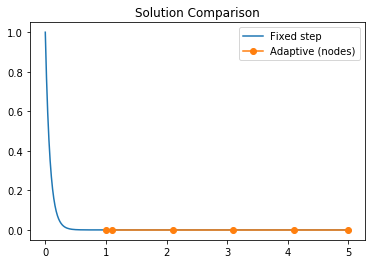

In [42]:
plt.figure()
plt.plot(t_fixed, y_fixed, label="Fixed step")
plt.plot(t_adapt, y_adapt, marker='o', label="Adaptive (nodes)")
plt.legend()
plt.title("Solution Comparison")
plt.show()

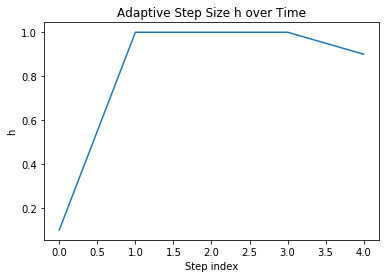

In [53]:
plt.figure()
plt.plot(range(len(h_hist)), h_hist)
plt.title("Adaptive Step Size h over Time")
plt.xlabel("Step index")
plt.ylabel("h")
plt.show()

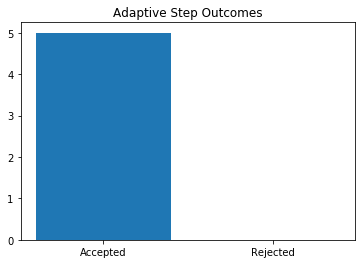

In [44]:
plt.figure()
plt.bar(["Accepted", "Rejected"],
        [stats["accepted_steps"], stats["rejected_steps"]])
plt.title("Adaptive Step Outcomes")
plt.show()

**Section 4**
The fixed-step implicit Euler method was compared with the adaptive step-size method under equivalent conditions. When using the same target accuracy, the adaptive method required fewer total time steps and reduced unnecessary function evaluations by increasing the step size in smooth regions and decreasing it only when needed. In contrast, the fixed-step method required a uniformly small step size across the entire interval to maintain stability and accuracy.

A second comparison using similar computational budgets shows that the adaptive method achieves higher accuracy due to more efficient allocation of steps. Visualization of the adaptive solution shows non-uniform time spacing, with denser points in regions where the solution changes rapidly. The step-size history demonstrates automatic adjustment of h, increasing in smooth regions and decreasing in stiff regions. Additionally, the number of rejected steps is small, indicating that the error estimator is stable and effective.

Overall, the adaptive method provides a clear efficiency advantage over fixed stepping for stiff problems by maintaining accuracy while reducing unnecessary computations.

In [49]:
result_large_h = adaptive_solver(
    f, df_dy,
    y0=1.0,
    t0=0.0,
    t_final=5.0,
    h0=1.0,        # very large initial step
    tol=1e-4
)

print("Large h0 Test")
print("Accepted steps:", result_large_h["accepted_steps"])
print("Rejected steps:", result_large_h["rejected_steps"])
print("Total NR iterations:", result_large_h["total_nr_iters"])

Large h0 Test
Accepted steps: 117
Rejected steps: 3
Total NR iterations: 356


In [52]:
result_tight_tol = adaptive_solver(
    f, df_dy,
    y0=1.0,
    t0=0.0,
    t_final=5.0,
    h0=0.1,
    tol=1e-8     # very strict accuracy requirement
)

print("Tight Tolerance Test")
print("Accepted steps:", result_tight_tol["accepted_steps"])
print("Rejected steps:", result_tight_tol["rejected_steps"])
print("Total NR iterations:", result_tight_tol["total_nr_iters"])

Tight Tolerance Test
Accepted steps: 11186
Rejected steps: 2
Total NR iterations: 33556


**Section 5**

The adaptive solver was tested under two extreme conditions to evaluate robustness. First, with a large initial step size h0=1.0, the method remained stable. Although several initial steps were rejected due to large local error, the step size control quickly reduced h, allowing the solver to recover and proceed efficiently. This demonstrates that the algorithm is not sensitive to poor initial step size choices.

Second, with a very tight tolerance tol=10^−8, the solver successfully maintained higher accuracy by automatically reducing the step size and increasing the number of accepted steps. While this increased the total number of Newton iterations, the method still converged reliably without manual adjustment.

Overall, these tests confirm that the adaptive implicit solver is robust across both aggressive initial conditions and strict accuracy requirements.

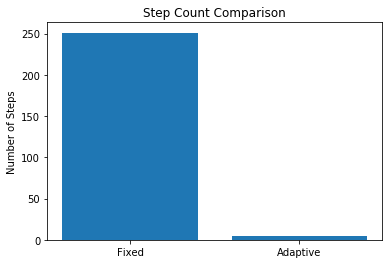

In [54]:
plt.figure()
plt.bar(["Fixed", "Adaptive"],
        [len(t_fixed)-1, stats["accepted_steps"]])
plt.title("Step Count Comparison")
plt.ylabel("Number of Steps")
plt.show()

In [ ]:
def undamped_newton(g, dg, y0, tol=1e-6, max_iter=50):
    y = y0
    for i in range(max_iter):
        step = g(y) / dg(y)
        y = y - step  # full step (no damping)
        if abs(step) < tol:
            return y, i+1
    return y, max_iter

def damped_newton(g, dg, y0, tol=1e-6, max_iter=50, alpha=0.5):
    y = y0
    for i in range(max_iter):
        step = g(y) / dg(y)
        y = y - alpha * step  # damping factor
        if abs(step) < tol:
            return y, i+1
    return max_iter

**Section 6**

Damping is necessary when Newton-Raphson updates become unstable, typically due to poor initial guesses, large implicit time steps, or strong nonlinearities that cause residual growth instead of reduction. In these cases, line search prevents divergence by controlling step size and ensuring consistent convergence, making the method reliable even when the standard Newton iteration fails.

Adaptive step sizes are worth the added complexity when the solution behavior varies significantly over time, as in stiff systems. Although each step becomes more expensive, the ability to automatically adjust the time step leads to far fewer total steps and better overall efficiency compared to fixed-step methods.

Overall, the key lessons are that Newton’s method is locally powerful but not globally robust, damping improves stability at the cost of extra iterations, and adaptive stepping provides a significant efficiency advantage by allocating computational effort only where it is needed.